# Part 4, Task 1 — Variational Autoencoder (VAE)
COMP3710 Lab Demonstration 2

**Important:** the real target dataset (Preprocessed OASIS brain MRI) lives only at
`/home/groups/comp3710/` on the Rangpur cluster — it is not available on this laptop. This
notebook builds and verifies the full VAE pipeline (architecture, loss, training loop,
manifold visualisation) locally on **MNIST** as a stand-in, since it is small, fast to download,
and grayscale like the OASIS slices. The final section shows exactly what changes to point this
same code at OASIS on Rangpur.

## 4.1.1 Data

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

transform = transforms.ToTensor()   # MNIST pixels already end up in [0, 1]
train_ds = torchvision.datasets.MNIST(root="/tmp/mnist_data", train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root="/tmp/mnist_data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print("train/test sizes:", len(train_ds), len(test_ds))

device: mps
train/test sizes: 60000 10000


## 4.1.2 The VAE architecture

**Encoder**: two convolutions shrink the 28x28 image down to a small 7x7 feature map, which is
flattened and fed to *two* separate linear layers — one predicting the mean (`mu`) and one the
log-variance (`logvar`) of a distribution over the latent space, rather than a single point.

**The reparameterisation trick**: we need to *sample* a random point from that distribution
(`mu`, `logvar`) during training, but "randomly sample" is not a differentiable operation — you
can't backpropagate through randomness directly. The trick: instead of sampling `z` directly from
`N(mu, var)`, sample `eps` from a fixed `N(0, 1)` and compute `z = mu + eps * std`. Now all the
*trainable* parameters (`mu`, `std`) go through ordinary differentiable arithmetic, and the
randomness (`eps`) is just an external input the gradient doesn't need to flow through.

**Decoder**: the mirror image of the encoder — a linear layer expands the small latent vector
back into a 7x7 feature map, and two transposed convolutions ("deconvolutions") upsample it back
to a full 28x28 image, with a final sigmoid so every pixel lands in [0, 1] (matching the input
range, needed for the reconstruction loss below).

**`latent_dim=2`**: deliberately tiny. A real VAE would usually use a much larger latent space
(e.g. 32, 64, or more dimensions) for better reconstruction quality, but a 2D latent space is
small enough to plot directly as an (x, y) plane — which is exactly what the manifold
visualisation in §4.1.5 needs.

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2, in_channels=1, img_size=28):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder: img_size -> img_size/2 -> img_size/4
        self.enc_conv1 = nn.Conv2d(in_channels, 32, 3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self._feat_size = img_size // 4
        flat_size = 64 * self._feat_size * self._feat_size
        self.enc_fc_mu = nn.Linear(flat_size, latent_dim)
        self.enc_fc_logvar = nn.Linear(flat_size, latent_dim)

        # Decoder: mirror of the encoder
        self.dec_fc = nn.Linear(latent_dim, flat_size)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, in_channels, 3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        h = F.relu(self.enc_conv1(x))
        h = F.relu(self.enc_conv2(h))
        h = h.flatten(1)
        return self.enc_fc_mu(h), self.enc_fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec_fc(z))
        h = h.view(-1, 64, self._feat_size, self._feat_size)
        h = F.relu(self.dec_conv1(h))
        return torch.sigmoid(self.dec_conv2(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


model = VAE(latent_dim=2, in_channels=1, img_size=28).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {n_params:,}")

Total params: 59,525


## 4.1.3 The loss function

```
Loss = reconstruction_loss + KL_divergence
```

- **Reconstruction loss** (binary cross-entropy here, since pixels are in [0,1] and can be treated
  as probabilities): how different is the reconstructed image from the original? Pushes the model
  to encode enough information to rebuild the input accurately.
- **KL divergence**: `-0.5 * sum(1 + logvar - mu^2 - exp(logvar))` — a closed-form formula for how
  far the encoded distribution `N(mu, var)` is from a standard normal `N(0, 1)`. Pushes every
  image's encoding towards the origin and towards variance 1, which is what keeps the latent space
  continuous and "fillable" rather than a few isolated islands.

These two terms pull in different directions (accurate-but-scattered vs. tidy-but-lossy), and
their balance is what makes VAE training distinctive compared to a plain autoencoder (which only
has the first term).

In [3]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

## 4.1.4 Training

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 20
history = {"loss": [], "recon": [], "kl": []}

t0 = time.time()
for epoch in range(n_epochs):
    model.train()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for xb, _ in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(xb)
        loss, recon_loss, kl_loss = vae_loss(recon, xb, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        n += xb.size(0)
    history["loss"].append(total_loss / n)
    history["recon"].append(total_recon / n)
    history["kl"].append(total_kl / n)
    if epoch % 4 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:2d}: loss={history['loss'][-1]:.2f}  recon={history['recon'][-1]:.2f}  kl={history['kl'][-1]:.2f}")

print(f"\nTraining time: {time.time() - t0:.2f}s on {device}")

epoch  0: loss=217.49  recon=210.69  kl=6.79


epoch  4: loss=162.48  recon=157.09  kl=5.39


epoch  8: loss=157.95  recon=152.30  kl=5.65


epoch 12: loss=156.00  recon=150.25  kl=5.75


epoch 16: loss=154.78  recon=148.97  kl=5.81


epoch 19: loss=154.10  recon=148.24  kl=5.86

Training time: 152.26s on mps


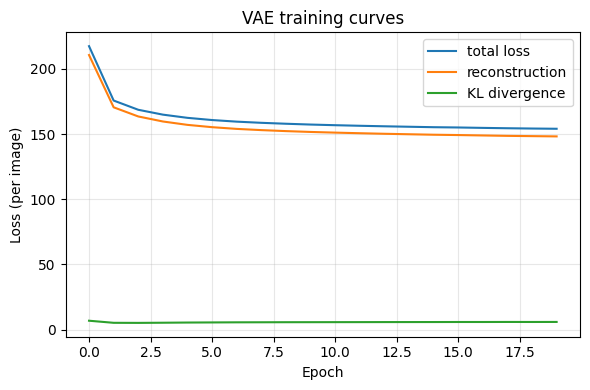

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(history["loss"], label="total loss")
plt.plot(history["recon"], label="reconstruction")
plt.plot(history["kl"], label="KL divergence")
plt.xlabel("Epoch"); plt.ylabel("Loss (per image)")
plt.title("VAE training curves")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.1.5 Visualising results

Three views, from most to least familiar:

1. **Reconstructions** — feed real test images through encode -> decode, compare to the originals.
2. **Latent scatter** — encode the whole test set into the 2D latent space, colour each point by
   its true digit label. If the VAE learned anything meaningful, different digits should occupy
   different (if overlapping) regions.
3. **The manifold** — the lab's required deliverable: sample a regular grid of points directly in
   the 2D latent plane (not from real data at all) and decode every single one, tiling the results
   into one image. This shows what the *entire learned space* looks like, not just the points that
   came from real images.

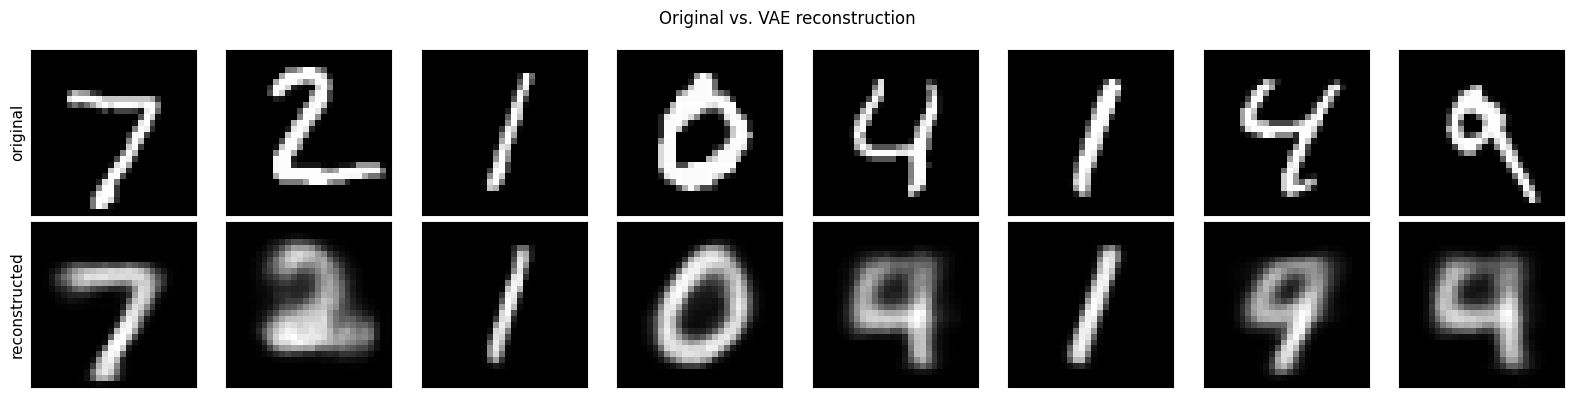

In [6]:
model.eval()
xb, _ = next(iter(test_loader))
xb = xb.to(device)
with torch.no_grad():
    recon, mu, logvar = model(xb)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    axes[0, i].imshow(xb[i, 0].cpu(), cmap="gray")
    axes[0, i].set_xticks(()); axes[0, i].set_yticks(())
    axes[1, i].imshow(recon[i, 0].cpu(), cmap="gray")
    axes[1, i].set_xticks(()); axes[1, i].set_yticks(())
axes[0, 0].set_ylabel("original", fontsize=11)
axes[1, 0].set_ylabel("reconstructed", fontsize=11)
plt.suptitle("Original vs. VAE reconstruction")
plt.tight_layout()
plt.show()

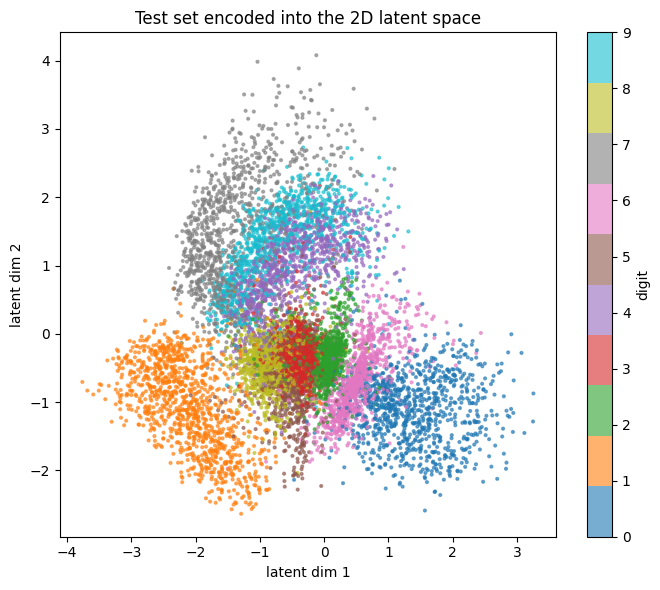

In [7]:
model.eval()
all_mu, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        mu, _ = model.encode(xb.to(device))
        all_mu.append(mu.cpu())
        all_labels.append(yb)
all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(7, 6))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap="tab10", s=4, alpha=0.6)
plt.colorbar(scatter, label="digit")
plt.xlabel("latent dim 1"); plt.ylabel("latent dim 2")
plt.title("Test set encoded into the 2D latent space")
plt.tight_layout()
plt.show()

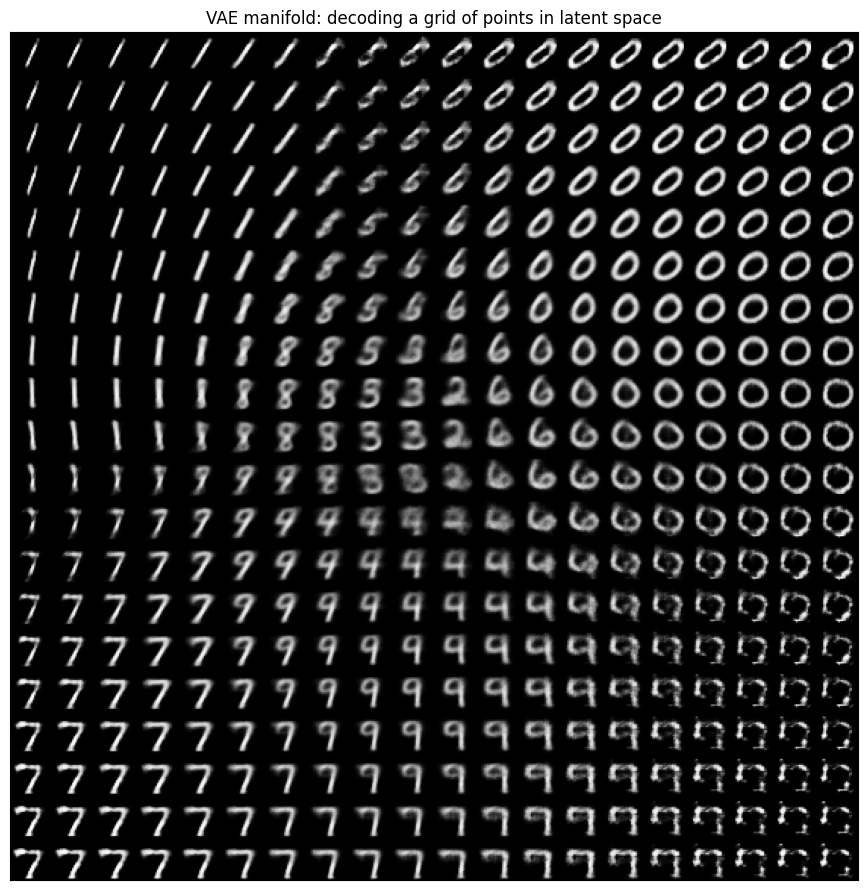

In [8]:
# Sample a grid of points directly in the latent plane and decode every one --
# this is "the manifold": what the model has learned to generate, not just what it has seen.
grid_n = 20
grid_range = 3.0   # +/- 3 standard deviations covers almost all of a standard normal
grid_x = np.linspace(-grid_range, grid_range, grid_n)
grid_y = np.linspace(-grid_range, grid_range, grid_n)

canvas = np.zeros((28 * grid_n, 28 * grid_n))
model.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32, device=device)
            img = model.decode(z).cpu().numpy().reshape(28, 28)
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img

plt.figure(figsize=(9, 9))
plt.imshow(canvas, cmap="gray")
plt.title("VAE manifold: decoding a grid of points in latent space")
plt.xticks(()); plt.yticks(())
plt.tight_layout()
plt.show()

**Discussion — reading the three visualisations:**

- **Reconstructions**: should look like blurrier, smoothed-out versions of the originals — some
  loss of sharp detail is expected and normal for a VAE (a side-effect of the KL term forcing a
  simpler, more compressed representation than a plain autoencoder would use).
- **Latent scatter**: digits sharing similar strokes/shapes (e.g. 4 and 9, or 3 and 8) usually end
  up in overlapping regions, while very distinct digits (e.g. 0 and 1) separate more cleanly. The
  whole cloud should be roughly centred on the origin and roughly circular — direct visual
  confirmation that the KL term is doing its job of pulling everything towards `N(0, 1)`.
- **The manifold**: moving smoothly across the grid should morph one digit gradually into another,
  with no jarring jumps or long stretches of meaningless noise. This is the real payoff of the VAE
  over a plain autoencoder: *every* point in this grid decodes to something plausible, even though
  none of them are copies of real training images — genuinely new samples from a continuous
  learned space, which is what the lab's required manifold visualisation is meant to demonstrate.

## 4.1.6 Porting to Rangpur — OASIS instead of MNIST

The model, loss function, and training loop above are dataset-agnostic — the only real work in
porting this is the **data loading**, since OASIS images will not come from a convenient
`torchvision.datasets` class the way MNIST does.

```python
import os
from PIL import Image
from torch.utils.data import Dataset

class OASISDataset(Dataset):
    """Adjust the directory layout / file extension once you've inspected the actual
    OASIS folder structure at /home/groups/comp3710/ on Rangpur -- this is a starting template,
    not a verified-correct implementation of an unseen directory layout."""
    def __init__(self, root, transform=None):
        self.paths = sorted(
            os.path.join(root, f) for f in os.listdir(root) if f.lower().endswith((".png", ".jpg"))
        )
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")   # "L" = single-channel grayscale
        if self.transform:
            img = self.transform(img)
        return img, 0   # no label needed -- VAE training is unsupervised


# On Rangpur:
oasis_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),   # match whatever size you choose
    transforms.ToTensor(),
])
train_ds = OASISDataset("/home/groups/comp3710/OASIS/train", transform=oasis_transform)
model = VAE(latent_dim=2, in_channels=1, img_size=img_size).to("cuda")
```

**What actually needs to change:**

- **The dataset class**: `torchvision.datasets.MNIST` -> a custom `Dataset` reading whatever
  format the OASIS files are actually stored in (check the real directory first — the template
  above assumes plain image files, but confirm the actual extension/layout on Rangpur before
  trusting it).
- **`img_size`**: OASIS brain slices are almost certainly not 28x28 — check the real image
  dimensions and pass the correct `img_size` into `VAE(...)`; the architecture already takes this
  as a parameter for exactly this reason, so no other code changes should be needed as long as the
  image size is evenly divisible by 4 (two stride-2 convolutions).
- **`latent_dim`**: 2 was chosen here purely so the manifold is directly plottable as a 2D grid.
  This still works for OASIS (a 2D manifold plot is the easiest way to satisfy the lab's
  visualisation requirement), though a larger latent dimension with a UMAP projection down to 2D
  (as the lab sheet also allows) may reconstruct brain MRI detail noticeably better — worth trying
  both if time permits.
- **`device="cuda"`**: same as Part 3.2.
- Everything else — the `VAE` class, `vae_loss`, the training loop, and the three visualisation
  cells — works unchanged once the `DataLoader` is feeding it correctly-shaped grayscale images.